In [ ]:
! pip install keras
!pip install scikit-learn

In [ ]:
import numpy as np
import pandas as pd
import cv2
import os
import seaborn as sns
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D,BatchNormalization,GlobalAveragePooling2D
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.callbacks import ReduceLROnPlateau
import shutil
import random

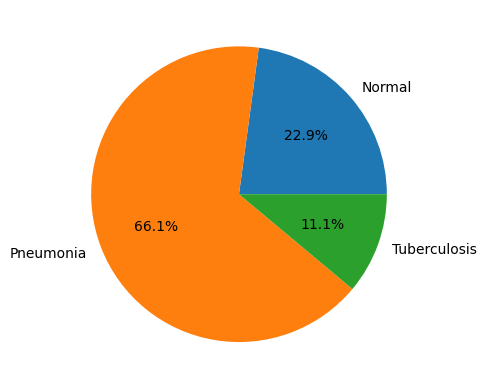

Số lượng ảnh normal: 1341
Số lượng ảnh pneumonia: 3875
Số lượng ảnh tuberculosis: 650


In [ ]:
path={'train':'/content/drive/MyDrive/DoAnCuoiCung/Disease/train','test':'/content/drive/MyDrive/DoAnCuoiCung/Disease/test','val':'/content/drive/MyDrive/DoAnCuoiCung/Disease/val'}

normal_path = path['train']+'/NORMAL'
pneumonia_path = path['train']+'/PNEUMONIA'
tuberculosis_path = path['train']+'/TURBERCULOSIS'

plt.pie(
    [len(os.listdir(normal_path)),
     len(os.listdir(pneumonia_path)),
     len(os.listdir(tuberculosis_path))],
     labels=['Normal','Pneumonia','Tuberculosis'],
     autopct='%1.1f%%')
plt.show()


print(f'Số lượng ảnh normal: {len(os.listdir(normal_path))}')
print(f'Số lượng ảnh pneumonia: {len(os.listdir(pneumonia_path))}')
print(f'Số lượng ảnh tuberculosis: {len(os.listdir(tuberculosis_path))}')

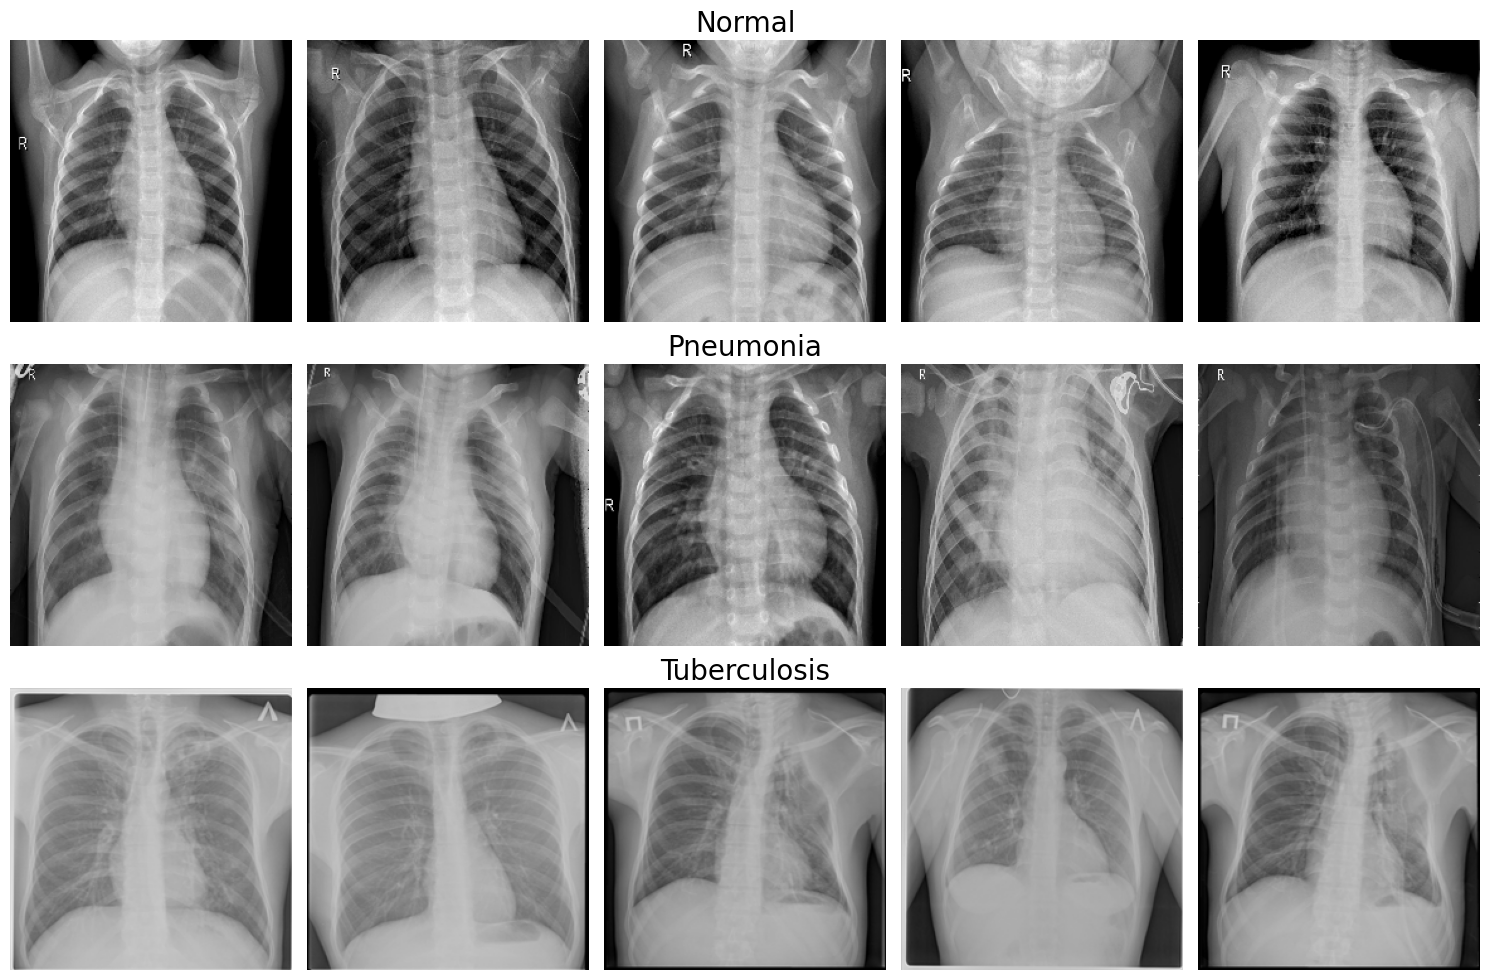

In [ ]:
# Đọc danh sách các ảnh từ thư mục
def get_images_from_directory(directory):
    image_paths = []
    for filename in os.listdir(directory):
        if filename.lower().endswith(('.jpg', '.png', '.jpeg')):
            image_paths.append(os.path.join(directory, filename))
    return image_paths

pneumonia_images = get_images_from_directory(pneumonia_path)
normal_images = get_images_from_directory(normal_path)
tuberculosis_images = get_images_from_directory(tuberculosis_path)

# Hàm xử lý và hiển thị ảnh
def process_and_display(images, row_idx, title):
    count = 0
    for i, image_path in enumerate(images):
        if count >= 5:
            break
        image = cv2.imread(image_path)
        image = cv2.resize(image, (224, 224))  # Resize ảnh về kích thước cố định
        plt.subplot(3, 5, row_idx * 5 + count + 1)  # Lưới 3 hàng x 5 cột
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))  # Đổi màu BGR sang RGB để hiển thị đúng
        plt.axis('off')
        if count == 2:
            plt.title(title, fontsize=20)  # Nhãn ở đầu hàng
        count += 1

# Tạo hình ảnh
plt.figure(figsize=(15, 10))

process_and_display(normal_images, 0, 'Normal')  # Hiển thị ảnh nhóm Normal
process_and_display(pneumonia_images, 1, 'Pneumonia')  # Hiển thị ảnh nhóm Pneumonia
process_and_display(tuberculosis_images, 2, 'Tuberculosis')  # Hiển thị ảnh nhóm Tuberculosis

plt.tight_layout()
plt.show()


In [ ]:
# Kiểm tra nếu folder chưa tồn tại thì tạo mới
balence_path = '/content/drive/MyDrive/do/Disease/Balance'
if not os.path.exists(balence_path):
    os.makedirs(balence_path)
    print(f"Folder {balence_path} đã được tạo.")
else:
    print(f"Folder {balence_path} đã tồn tại.")

Folder /content/drive/MyDrive/do/Disease/Balance đã được tạo.


Current count of images in /content/drive/MyDrive/do/Disease/Balance/NORMAL: 650
Already reached target size. No need to copy more images.
Current count of images in /content/drive/MyDrive/do/Disease/Balance/PNEUMONIA: 650
Already reached target size. No need to copy more images.


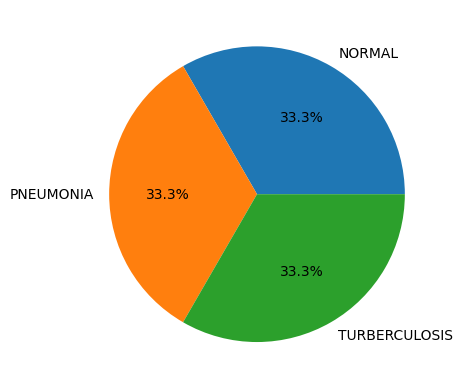

Số lượng ảnh NORMAL: 650
Số lượng ảnh PNEUMONIA: 650
Số lượng ảnh TURBERCULOSIS: 650


In [ ]:

def undersample_images(input_dir, output_dir, target_size=650):
    os.makedirs(output_dir, exist_ok=True)

    # Kiểm tra số lượng ảnh đã có trong thư mục đích
    current_count = len(os.listdir(output_dir))
    print(f"Current count of images in {output_dir}: {current_count}")

    # Nếu số lượng ảnh đã đủ, không cần sao chép thêm
    if current_count >= target_size:
        print("Already reached target size. No need to copy more images.")
        return
    # Lấy ngẫu nhiên ảnh từ input_dir
    images = os.listdir(input_dir)
    num_images_to_copy = target_size - current_count
    sampled_images = random.sample(images, num_images_to_copy)  # Lấy ngẫu nhiên ảnh cần thêm

    for img_name in sampled_images:
        shutil.copy(os.path.join(input_dir, img_name), os.path.join(output_dir, img_name))


# Thư mục hiện tại
undersample_images(path['train']+'/NORMAL', "/content/drive/MyDrive/do/Disease/Balance/NORMAL", 650)
undersample_images(path['train']+'/PNEUMONIA', "/content/drive/MyDrive/do/Disease/Balance/PNEUMONIA", 650)

# Kiểm tra ảnh trong trong các thư mục trên
balance_path = '/content/drive/MyDrive/do/Disease/Balance'
balance_class= ['NORMAL', 'PNEUMONIA','TURBERCULOSIS']

plt.pie([len(os.listdir(balance_path+"/"+cls)) for cls in balance_class],
        labels=balance_class,
        autopct='%1.1f%%')
plt.show()
for cls in balance_class:
  print(f'Số lượng ảnh {cls}: {len(os.listdir(balance_path+"/"+cls))}')

In [ ]:

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=3,
    preprocessing_function=preprocess_input,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=False,
    fill_mode='nearest',
    validation_split=0.2
)


train_generator = train_datagen.flow_from_directory(
    balance_path,  # Đường dẫn tới thư mục train
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    balance_path,  # Đường dẫn tới thư mục val
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'

)

Found 1560 images belonging to 3 classes.
Found 390 images belonging to 3 classes.


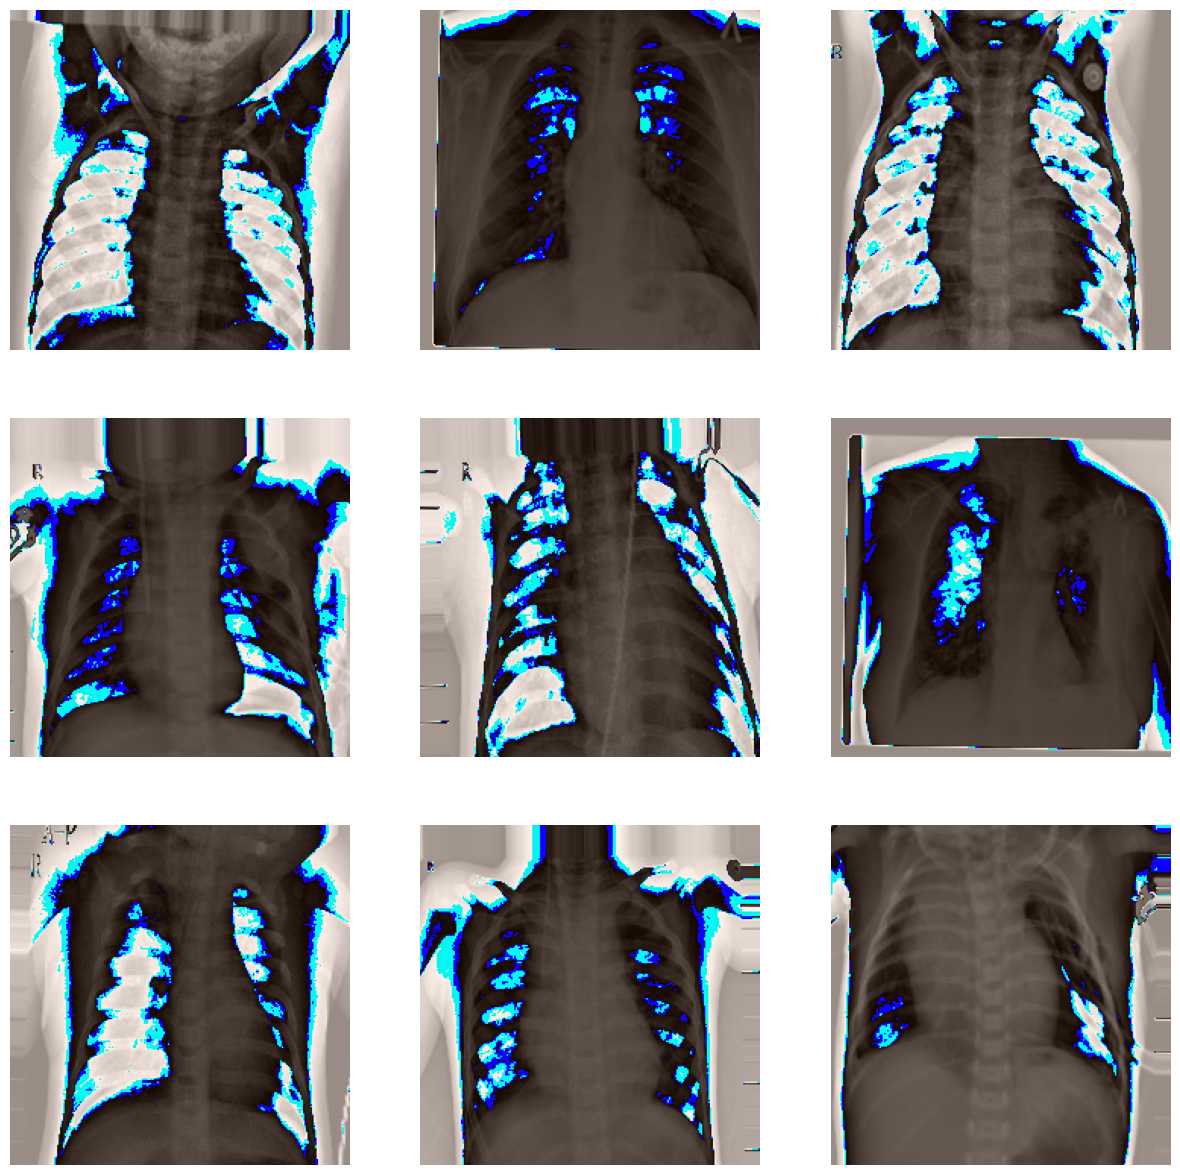

In [ ]:
# Visualizando alguns exemplos do dataset por meio do Generator criado
plt.figure(figsize=(15, 15))
for i in range(9):
    # Gera subfiguras
    plt.subplot(330 + 1 + i)

    # Lấy một batch ảnh từ generator
    batch = next(train_generator)
    image = batch[0][i] * 255
    image = image.astype('uint8')
    plt.imshow(image)
    plt.axis('off')
plt.show()

In [ ]:
from tensorflow.keras.applications import ResNet50
def create_model(input_shape):
    # Sử dụng ResNet50 với pre-trained weights từ ImageNet
    base_model = ResNet50(include_top=False, weights='imagenet', input_tensor=None, input_shape=input_shape, pooling=None)

    # Đóng băng các lớp của ResNet50
    base_model.trainable = False

    # Tạo mô hình với ResNet50 làm base model
    model = Sequential()

    # Thêm base model ResNet50 vào mô hình
    model.add(base_model)

    # Thêm lớp GlobalAveragePooling để giảm kích thước và trích xuất đặc trưng
    model.add(GlobalAveragePooling2D())

    # Thêm các lớp fully connected (Dense)
    model.add(Dense(256, activation="relu"))
    model.add(Dense(128, activation="relu"))
    model.add(Dropout(0.3))  # Giảm overfitting
    model.add(Dense(3, activation="softmax"))  # Sử dụng softmax cho phân loại đa lớp

    # Compile mô hình
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    return model

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)                │ (None, 7, 7, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_2           │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 256)                 │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 24,145,539 (92.11 MB)

 Trainable params: 557,827 (2.13 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

None


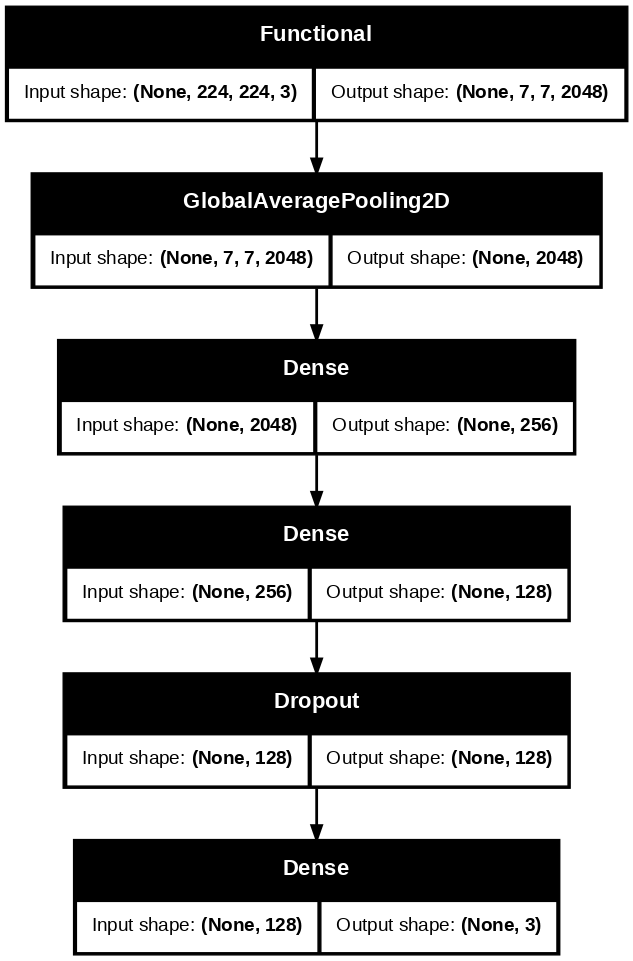

In [ ]:
from keras.utils import plot_model
image_shape = (224,224,3)
model = create_model(image_shape)
print(model.summary())
plot_model(model, show_shapes=True, dpi=100)

In [ ]:

early_stopping = EarlyStopping(monitor='val_loss', patience=10, verbose=1, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_model_resnet50.keras', monitor='val_loss', save_best_only=True, verbose=1)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,           # Giảm learning rate xuống 50% so với hiện tại
    patience=5,           # Chờ 5 epoch nếu không có cải thiện
    min_lr=1e-6,          # Không giảm dưới 1e-6
    verbose=1
)

history = model.fit(
    train_generator,
    epochs=50,
    validation_data=val_generator,
    callbacks=[early_stopping, checkpoint,reduce_lr]
)

Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 799ms/step - accuracy: 0.3581 - loss: 1.1613
Epoch 1: val_loss improved from inf to 1.08587, saving model to best_model_resnet50.keras
49/49 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.3578 - loss: 1.1607 - val_accuracy: 0.3564 - val_loss: 1.0859 - learning_rate: 0.0010
Epoch 2/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 794ms/step - accuracy: 0.3868 - loss: 1.0919
Epoch 2: val_loss did not improve from 1.08587
49/49 ━━━━━━━━━━━━━━━━━━━━ 55s 997ms/step - accuracy: 0.3867 - loss: 1.0919 - val_accuracy: 0.3333 - val_loss: 1.0948 - learning_rate: 0.0010
Epoch 3/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 725ms/step - accuracy: 0.3808 - loss: 1.0918
Epoch 3: val_loss improved from 1.08587 to 1.07246, saving model to best_model_resnet50.keras
49/49 ━━━━━━━━━━━━━━━━━━━━ 50s 917ms/step - accuracy: 0.3815 - loss: 1.0915 - val_accuracy: 0.3333 - val_loss: 1.0725 - learning_rate: 0.0010
Epoch 4/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 721ms/step - accuracy: 0.3981 - loss: 1.0751
Epoch 4: val_

In [ ]:
print(os.listdir(path['test']))

['TURBERCULOSIS', 'PNEUMONIA', 'NORMAL']


In [ ]:
# Định nghĩa ImageDataGenerator cho dữ liệu kiểm tra
test_datagen = ImageDataGenerator(
    rescale=1./255,
    preprocessing_function=preprocess_input
    )

# Tạo test_generator
test_generator = test_datagen.flow_from_directory(
    path['test'],  # Đường dẫn tới thư mục test
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)


# Đánh giá mô hình trên tập test
test_loss, test_accuracy = model.evaluate(val_generator)
print(f"Test Loss: {test_loss}")
print(f'Test accuracy: {test_accuracy}')
# Đánh giá mô hình trên tập train
test_loss, test_accuracy = model.evaluate(train_generator)
print(f"Test Loss: {test_loss}")
print(f'Test accuracy: {test_accuracy}')
# Đánh giá mô hình trên tập train
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss}")
print(f'Test accuracy: {test_accuracy}')

Found 665 images belonging to 3 classes.
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 630ms/step - accuracy: 0.8355 - loss: 0.3501
Test Loss: 0.3642791211605072
Test accuracy: 0.8307692408561707
49/49 ━━━━━━━━━━━━━━━━━━━━ 40s 800ms/step - accuracy: 0.8683 - loss: 0.3600
Test Loss: 0.3493853807449341
Test accuracy: 0.8711538314819336


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


21/21 ━━━━━━━━━━━━━━━━━━━━ 138s 7s/step - accuracy: 0.7680 - loss: 0.5567
Test Loss: 0.46013912558555603
Test accuracy: 0.8060150146484375


In [ ]:
import seaborn as sns
# Dự đoán trên test_generator
predictions = model.predict(test_generator, verbose=1)

# Dự đoán lớp với giá trị xác suất cao nhất
predicted_classes = np.argmax(predictions, axis=1)

# Lấy các nhãn thật từ test_generator
true_classes = test_generator.classes

# Tạo confusion matrix
conf_matrix = confusion_matrix(true_classes, predicted_classes)

# Vẽ confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(test_generator.class_indices.keys()),
            yticklabels=list(test_generator.class_indices.keys()))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
predictions = model.predict(test_generator)  # Kết quả là xác suất
y_pred = np.argmax(predictions, axis=1)      # Lấy nhãn dự đoán từ xác suất
y_true = test_generator.classes              # Nhãn thực tế

# Lấy danh sách tên lớp từ test_generator
class_names = list(test_generator.class_indices.keys())

21/21 ━━━━━━━━━━━━━━━━━━━━ 69s 3s/step


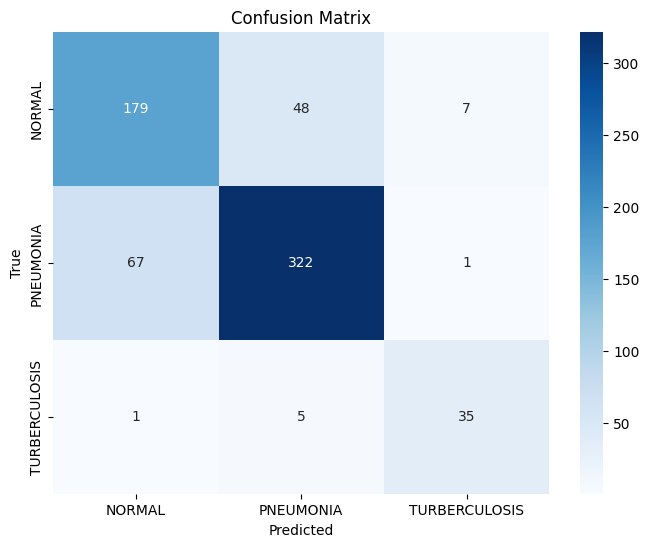

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

Accuracy: 0.81
Precision: 0.81
Recall: 0.81
F1-Score: 0.81
Classification Report:
               precision    recall  f1-score   support

       NORMAL       0.72      0.76      0.74       234
    PNEUMONIA       0.86      0.83      0.84       390
TURBERCULOSIS       0.81      0.85      0.83        41

     accuracy                           0.81       665
    macro avg       0.80      0.81      0.81       665
 weighted avg       0.81      0.81      0.81       665



In [ ]:
model = load_model('/content/best_model_resnet50.keras')

In [ ]:
new_image_path = "/content/drive/MyDrive/do/Disease/val/TURBERCULOSIS/Tuberculosis-1.png"
test_image = load_img(new_image_path, target_size = (224, 224))
test_image = img_to_array(test_image)
test_image = np.expand_dims(test_image, axis = 0)
test_image = test_image / 255.0  # Chuẩn hóa giá trị pixel

# Dự đoán
result = model.predict(test_image)

# Xử lý kết quả dự đoán cho 3 lớp
class_indices = train_generator.class_indices
class_labels = list(class_indices.keys())  # Danh sách các lớp

# Dự đoán lớp có xác suất cao nhất
predicted_class_index = np.argmax(result, axis=1)[0]
prediction = class_labels[predicted_class_index]

for i, label in enumerate(class_labels):
    print(f"{label}: {result[0][i] * 100:.2f}%")

print(f"\nPredicted Class: {prediction}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 507ms/step
NORMAL: 0.12%
PNEUMONIA: 0.25%
TURBERCULOSIS: 99.63%

Predicted Class: TURBERCULOSIS


VGG16

In [ ]:
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess_input

train_datagen = ImageDataGenerator(
    rotation_range=3,
    preprocessing_function=vgg16_preprocess_input,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    fill_mode='nearest',
    validation_split=0.2
)


train_generator = train_datagen.flow_from_directory(
    balance_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

# Tạo generator cho tập validation
val_generator = train_datagen.flow_from_directory(
    balance_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)


test_datagen = ImageDataGenerator(
    preprocessing_function=vgg16_preprocess_input
    )

# Tạo test_generator
test_generator = test_datagen.flow_from_directory(
    path['test'],  # Đường dẫn tới thư mục test
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

def create_model_vgg16(input_shape):
    # Sử dụng VGG16 với pre-trained weights từ ImageNet
    base_model = VGG16(include_top=False, weights='imagenet', input_tensor=None, input_shape=input_shape, pooling='max')

    # Đóng băng các lớp của VGG16
    base_model.trainable = False

    # Tạo mô hình với VGG16 làm base model
    model = Sequential()

    # Thêm base model VGG16 vào mô hình
    model.add(base_model)

    # Thêm các lớp fully connected (Dense)
    model.add(Dense(256, activation="relu"))
    model.add(Dense(128, activation="relu"))
    model.add(Dropout(0.3))  # Giảm overfitting
    model.add(Dense(3, activation="softmax"))  # Sử dụng softmax cho phân loại đa lớp

    # Compile mô hình
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    return model

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)                   │ (None, 512)                 │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,879,299 (56.76 MB)

 Trainable params: 164,611 (643.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

None


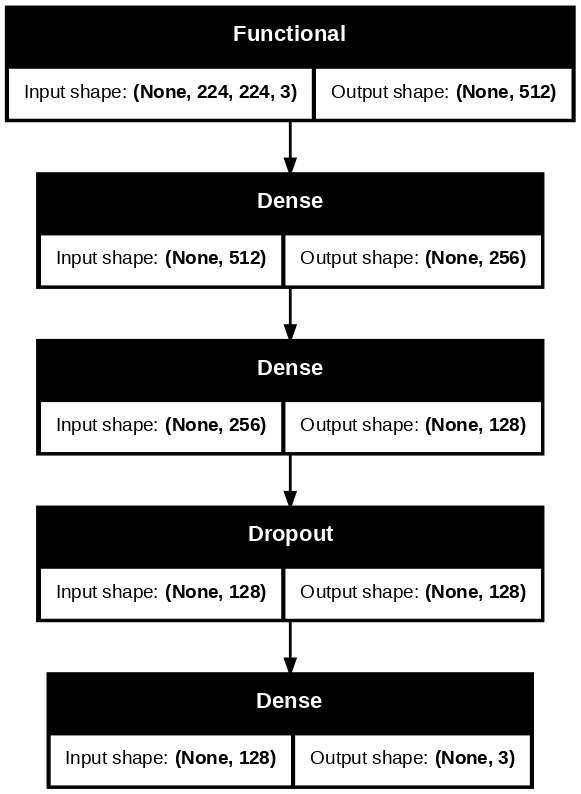

In [ ]:
image_shape = (224,224,3)
model = create_model_vgg16(image_shape)
print(model.summary())
plot_model(model, show_shapes=True, dpi=100)

In [ ]:
early_stopping = EarlyStopping(monitor='val_loss', patience=10, verbose=1, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_model_vgg16.keras', monitor='val_loss', save_best_only=True, verbose=1)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,           # Giảm learning rate xuống 50% so với hiện tại
    patience=5,           # Chờ 5 epoch nếu không có cải thiện
    min_lr=1e-6,          # Không giảm dưới 1e-6
    verbose=1
)

history = model.fit(
    train_generator,
    epochs=50,
    validation_data=val_generator,
    callbacks=[early_stopping, checkpoint,reduce_lr]
)

Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.6783 - loss: 5.8667
Epoch 1: val_loss improved from inf to 1.08918, saving model to best_model_vgg16.keras
49/49 ━━━━━━━━━━━━━━━━━━━━ 620s 11s/step - accuracy: 0.6805 - loss: 5.8082 - val_accuracy: 0.8590 - val_loss: 1.0892 - learning_rate: 0.0010
Epoch 2/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 683ms/step - accuracy: 0.8754 - loss: 0.8088
Epoch 2: val_loss improved from 1.08918 to 0.34906, saving model to best_model_vgg16.keras
49/49 ━━━━━━━━━━━━━━━━━━━━ 53s 892ms/step - accuracy: 0.8756 - loss: 0.8059 - val_accuracy: 0.9179 - val_loss: 0.3491 - learning_rate: 0.0010
Epoch 3/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 715ms/step - accuracy: 0.9027 - loss: 0.3901
Epoch 3: val_loss improved from 0.34906 to 0.32398, saving model to best_model_vgg16.keras
49/49 ━━━━━━━━━━━━━━━━━━━━ 49s 895ms/step - accuracy: 0.9029 - loss: 0.3891 - val_accuracy: 0.8872 - val_loss: 0.3240 - learning_rate: 0.0010
Epoch 4/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 697ms/step - accuracy

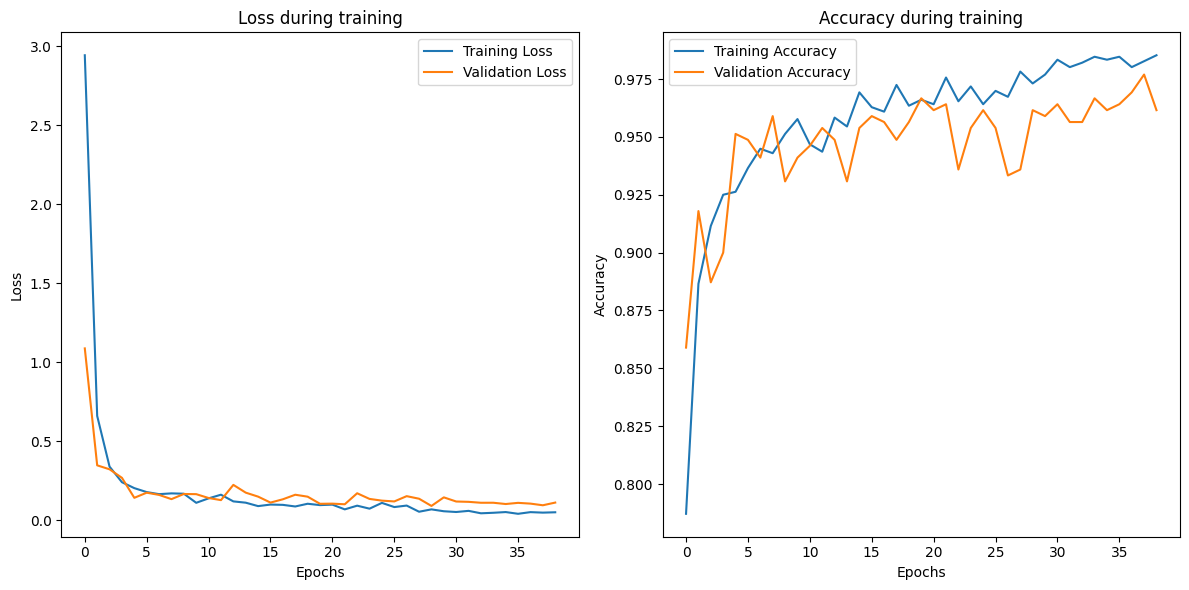

In [ ]:
# Vẽ biểu đồ loss và accuracy
plt.figure(figsize=(12, 6))

# Vẽ Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss during training')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Vẽ Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy during training')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Hiển thị biểu đồ
plt.tight_layout()
plt.show()

21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 377ms/step


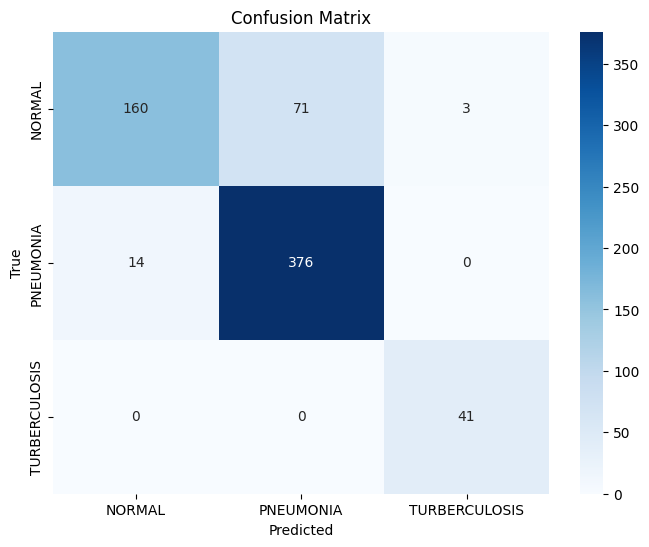

In [ ]:
predictions = model.predict(test_generator)  # Kết quả là xác suất
y_pred = np.argmax(predictions, axis=1)      # Lấy nhãn dự đoán từ xác suất
y_true = test_generator.classes              # Nhãn thực tế

# Lấy danh sách tên lớp từ test_generator
class_names = list(test_generator.class_indices.keys())
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

Accuracy: 0.87
Precision: 0.87
Recall: 0.87
F1-Score: 0.86
Classification Report:
               precision    recall  f1-score   support

       NORMAL       0.92      0.68      0.78       234
    PNEUMONIA       0.84      0.96      0.90       390
TURBERCULOSIS       0.93      1.00      0.96        41

     accuracy                           0.87       665
    macro avg       0.90      0.88      0.88       665
 weighted avg       0.87      0.87      0.86       665



In [ ]:
new_image_path = "/content/drive/MyDrive/DoAnCuoiCung/Disease/val/PNEUMONIA/person1946_bacteria_4875.jpeg"
test_image = load_img(new_image_path, target_size = (224, 224))
test_image = img_to_array(test_image)
test_image = np.expand_dims(test_image, axis = 0)
test_image = vgg16_preprocess_input(test_image)

# Dự đoán
result = model.predict(test_image)

# Xử lý kết quả dự đoán cho 3 lớp
class_indices = train_generator.class_indices
class_labels = list(class_indices.keys())  # Danh sách các lớp

# Dự đoán lớp có xác suất cao nhất
predicted_class_index = np.argmax(result, axis=1)[0]
prediction = class_labels[predicted_class_index]

for i, label in enumerate(class_labels):
    print(f"{label}: {result[0][i] * 100:.2f}%")

print(f"\nPredicted Class: {prediction}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
NORMAL: 0.01%
PNEUMONIA: 99.97%
TURBERCULOSIS: 0.02%

Predicted Class: PNEUMONIA
